# 03. Turning Business Questions into Causal Questions

The previous notebook gave us LLM mechanics: prompts, chat templates, structured outputs, reproducibility, hallucination checks, and model comparison. This notebook moves back into causal workflow.

The central skill is translation. Stakeholders rarely ask causal questions in a clean statistical form. They ask questions like:

- Did outreach work?
- Did the new ranking algorithm improve engagement?
- Are discounts hurting revenue?
- Did the AI assistant reduce support burden?

Those are business questions. A causal analyst has to convert them into questions with a unit, treatment, comparison condition, outcome, time window, target population, estimand, and decision context.

AI can help with this translation, but only if we make the model produce reviewable artifacts rather than confident conclusions.


## Learning Goals

By the end of this notebook, you should be able to:

- Separate business ambiguity from causal structure.
- Rewrite stakeholder questions using a causal-question grammar.
- Identify missing information before estimation begins.
- Distinguish causal, predictive, descriptive, and diagnostic questions.
- Use structured schemas to make AI-generated causal questions auditable.
- Score model outputs on causal-question quality.
- Compare all available local models on a focused translation task when running interactively.


## Live Model Note

This course treats LLM behavior as an empirical object. These notebooks may include live local-model calls, so outputs can vary across model versions, hardware, decoding settings, prompt wording, package versions, and reruns. That instability is part of the lesson: AI-assisted causal inference requires validation, audit trails, and analyst judgment.

Treat model output as a draft artifact, not as causal evidence. A model may produce valid JSON with weak causal reasoning, or strong prose that fails schema validation.

When live calls are enabled, read the results as experiments about AI behavior:

- Did the model invent design details?
- Did it confuse prediction with causation?
- Did it recommend bad controls?
- Did it obey the schema?
- Did it surface missing information?
- Did it preserve uncertainty?

The goal is not to make every model output perfect. The goal is to learn how to build AI-assisted causal workflows that are auditable, constrained, and reviewed by a human analyst.

## 1. Setup

This notebook is safe to render publicly. Live local LLM calls are optional and disabled by default. The deterministic examples below play the role of AI-generated drafts so the lecture remains reproducible.


In [107]:
import gc
import importlib.util
import json
import re
import textwrap
from functools import lru_cache

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import Markdown, display
from pydantic import BaseModel, Field, ValidationError

pd.set_option('display.max_colwidth', 140)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', context='notebook')


In [108]:
RUN_LIVE_LOCAL_LLM = True
RUN_FULL_MODEL_COMPARISON = True
RUN_SCHEMA_REPAIR_RETRY = True

LOCAL_SMOKE_TEST_MODEL = 'Qwen/Qwen2.5-0.5B-Instruct'
LOCAL_FAST_MODEL = 'Qwen/Qwen2.5-7B-Instruct'
LOCAL_STRONG_MODEL = 'Qwen/Qwen2.5-14B-Instruct'
LOCAL_SCALE_MODEL = 'Qwen/Qwen2.5-32B-Instruct'

LOCAL_ALT_REASONING_MODEL = 'microsoft/Phi-3.5-mini-instruct'
LOCAL_ALT_OPEN_MODEL = 'mistralai/Mistral-7B-Instruct-v0.3'
LOCAL_MISTRAL_SMALL_MODEL = 'mistralai/Mistral-Small-3.1-24B-Instruct-2503'
LOCAL_GEMMA_MODEL = 'google/gemma-3-27b-it'
LOCAL_LLAMA_MODEL = 'meta-llama/Meta-Llama-3.1-8B-Instruct'

MODEL_ID = LOCAL_FAST_MODEL
MAX_NEW_TOKENS = 600
TEMPERATURE = 0.0
SEED = 123

MODELS_TO_COMPARE = [
    ('Qwen 0.5B', LOCAL_SMOKE_TEST_MODEL, 'pipeline smoke test'),
    ('Qwen 7B', LOCAL_FAST_MODEL, 'fast default'),
    ('Qwen 14B', LOCAL_STRONG_MODEL, 'strong local analysis'),
    ('Qwen 32B', LOCAL_SCALE_MODEL, 'scale comparison'),
    ('Phi mini', LOCAL_ALT_REASONING_MODEL, 'compact non-Qwen comparison'),
    ('Mistral 7B', LOCAL_ALT_OPEN_MODEL, '7B model-family comparison'),
    ('Mistral Small 24B', LOCAL_MISTRAL_SMALL_MODEL, 'strong non-Qwen comparison'),
    ('Gemma 3 27B', LOCAL_GEMMA_MODEL, 'large non-Qwen comparison'),
    ('Llama 3.1 8B', LOCAL_LLAMA_MODEL, 'industry-standard instruct baseline'),
]


In [109]:
def has_package(module_name):
    return importlib.util.find_spec(module_name) is not None


DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

environment_report = pd.DataFrame(
    [
        ('torch', True, torch.__version__),
        ('cuda available', torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else ''),
        ('transformers', has_package('transformers'), ''),
        ('accelerate', has_package('accelerate'), ''),
        ('torchvision', has_package('torchvision'), 'needed for Gemma 3 processor path'),
        ('pydantic', has_package('pydantic'), ''),
    ],
    columns=['component', 'available', 'details'],
)

environment_report


,component,available,details
0,torch,True,2.11.0+cu130
1,cuda available,True,NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition
2,transformers,True,
3,accelerate,True,
4,torchvision,True,needed for Gemma 3 processor path
5,pydantic,True,


## 2. Business Questions Are Usually Underspecified

A business question is often decision-oriented but statistically incomplete. It may name a program or product change, but omit the comparison condition, target population, timing, measurement window, or decision rule.

A causal question needs more structure:

```text
Among [target population], what is the effect of [treatment] compared with [comparison condition]
on [outcome] over [time window] for [decision context]?
```

That grammar is simple, but it changes the work. It forces the analyst to ask whether the data can support the question before estimating anything.


In [110]:
business_questions = pd.DataFrame(
    [
        {'case_id': 'retention', 'stakeholder_question': 'Did proactive outreach reduce churn?', 'domain': 'customer success', 'decision': 'Should we scale the outreach program next quarter?'},
        {'case_id': 'ranking', 'stakeholder_question': 'Did the new ranking model improve engagement?', 'domain': 'recommendation systems', 'decision': 'Should we keep the new ranking model in production?'},
        {'case_id': 'pricing', 'stakeholder_question': 'Are discounts hurting revenue?', 'domain': 'pricing', 'decision': 'Should sales teams reduce discounting authority?'},
        {'case_id': 'ai_support', 'stakeholder_question': 'Did the AI support assistant reduce ticket volume?', 'domain': 'AI systems', 'decision': 'Should the assistant be rolled out to all support queues?'},
        {'case_id': 'onboarding', 'stakeholder_question': 'Does the new onboarding flow help users activate?', 'domain': 'product', 'decision': 'Should the new flow become the default?'},
        {'case_id': 'training', 'stakeholder_question': 'Did the analyst training program improve productivity?', 'domain': 'operations', 'decision': 'Should the training be required for new analysts?'},
    ]
)

business_questions


,case_id,stakeholder_question,domain,decision
0,retention,Did proactive outreach reduce churn?,customer success,Should we scale the outreach program next quarter?
1,ranking,Did the new ranking model improve engagement?,recommendation systems,Should we keep the new ranking model in production?
2,pricing,Are discounts hurting revenue?,pricing,Should sales teams reduce discounting authority?
3,ai_support,Did the AI support assistant reduce ticket volume?,AI systems,Should the assistant be rolled out to all support queues?
4,onboarding,Does the new onboarding flow help users activate?,product,Should the new flow become the default?
5,training,Did the analyst training program improve productivity?,operations,Should the training be required for new analysts?


### Discussion

Every question above is reasonable as a stakeholder question. None is yet enough for causal analysis.

For example, "Did the new ranking model improve engagement?" could mean:

- effect on users exposed to the model or all eligible users;
- effect versus the previous ranking model or versus no personalization;
- clicks, sessions, purchases, long-run retention, or satisfaction;
- immediate engagement or engagement over several weeks;
- average effect, effect on treated users, effect on a launch cohort, or effect on heavy users.

An LLM can help enumerate those interpretations. The analyst must decide which interpretation supports the actual decision.


## 3. Causal, Predictive, Descriptive, and Diagnostic Questions

Before rewriting a stakeholder request, classify it. Many requests that sound causal are actually predictive or descriptive.


In [111]:
question_types = pd.DataFrame(
    [
        ('causal', 'What would happen to an outcome if we changed a treatment?', 'Would proactive outreach reduce 90-day churn if assigned to eligible high-risk accounts?', 'Requires an identification strategy and assumptions.'),
        ('predictive', 'What outcome is likely for a unit?', 'Which accounts are most likely to churn next month?', 'Useful for targeting, but not an effect estimate.'),
        ('descriptive', 'What happened in the observed data?', 'What was churn among contacted and non-contacted accounts?', 'Useful context, but not a causal answer.'),
        ('diagnostic', 'Is the data/design credible enough for a causal analysis?', 'Do contacted and non-contacted accounts overlap on pre-treatment risk?', 'Often the right first question before estimation.'),
    ],
    columns=['question type', 'core question', 'example', 'analyst warning'],
)

question_types


,question type,core question,example,analyst warning
0,causal,What would happen to an outcome if we changed a treatment?,Would proactive outreach reduce 90-day churn if assigned to eligible high-risk accounts?,Requires an identification strategy and assumptions.
1,predictive,What outcome is likely for a unit?,Which accounts are most likely to churn next month?,"Useful for targeting, but not an effect estimate."
2,descriptive,What happened in the observed data?,What was churn among contacted and non-contacted accounts?,"Useful context, but not a causal answer."
3,diagnostic,Is the data/design credible enough for a causal analysis?,Do contacted and non-contacted accounts overlap on pre-treatment risk?,Often the right first question before estimation.


## 4. A Structured Causal-Question Draft

The safest AI output here is not prose. It is a structured draft that can be validated.

The schema below is intentionally a design artifact, not an estimation artifact. It asks the model to state what must be known before choosing a method.


In [112]:
class CausalQuestionDraft(BaseModel):
    case_id: str
    stakeholder_question: str
    question_type: str
    decision: str
    unit: str
    target_population: str
    treatment: str
    comparison: str
    outcome: str
    time_window: str
    estimand: str
    assignment_mechanism: str
    required_assumptions: list[str] = Field(min_length=1)
    missing_information: list[str] = Field(default_factory=list)
    risks_if_answered_naively: list[str] = Field(default_factory=list)
    analyst_next_steps: list[str] = Field(default_factory=list)


schema_fields = pd.DataFrame(
    [
        ('unit', 'What object receives treatment and contributes an outcome?', 'customer account, user, session, store, employee'),
        ('target_population', 'Who is the estimand about?', 'eligible accounts, new users, support queues'),
        ('treatment', 'What intervention or exposure is being changed?', 'outreach, ranking model, discount, AI assistant'),
        ('comparison', 'What counterfactual condition is treatment compared to?', 'no outreach, old ranking model, standard support'),
        ('outcome', 'What metric will be affected?', 'churn, activation, revenue, ticket volume'),
        ('time_window', 'When is treatment measured and when is outcome measured?', '30-day activation, 90-day churn'),
        ('estimand', 'Which causal quantity is targeted?', 'ATE, ATT, policy value, effect among eligible users'),
        ('assignment_mechanism', 'How did units receive treatment?', 'randomized, targeted, self-selected, rollout rule'),
        ('missing_information', 'What must be clarified before estimation?', 'eligibility, timing, logging, confounders'),
    ],
    columns=['field', 'question it answers', 'examples'],
)

schema_fields


,field,question it answers,examples
0,unit,What object receives treatment and contributes an outcome?,"customer account, user, session, store, employee"
1,target_population,Who is the estimand about?,"eligible accounts, new users, support queues"
2,treatment,What intervention or exposure is being changed?,"outreach, ranking model, discount, AI assistant"
3,comparison,What counterfactual condition is treatment compared to?,"no outreach, old ranking model, standard support"
4,outcome,What metric will be affected?,"churn, activation, revenue, ticket volume"
5,time_window,When is treatment measured and when is outcome measured?,"30-day activation, 90-day churn"
6,estimand,Which causal quantity is targeted?,"ATE, ATT, policy value, effect among eligible users"
7,assignment_mechanism,How did units receive treatment?,"randomized, targeted, self-selected, rollout rule"
8,missing_information,What must be clarified before estimation?,"eligibility, timing, logging, confounders"


## 5. Example Translations

Below are deterministic drafts for the six business questions. In a live workflow, an LLM could produce drafts like these. The analyst would then review, correct, and approve them.


In [113]:
draft_records = [
    {
        'case_id': 'retention',
        'stakeholder_question': 'Did proactive outreach reduce churn?',
        'question_type': 'causal',
        'decision': 'Decide whether to scale proactive customer-success outreach next quarter.',
        'unit': 'customer account',
        'target_population': 'eligible accounts that could have received outreach at the start of the quarter',
        'treatment': 'assignment to proactive customer-success outreach',
        'comparison': 'standard customer-success process without proactive outreach',
        'outcome': 'customer churn indicator',
        'time_window': 'churn measured within 90 days after outreach eligibility',
        'estimand': 'ATE among eligible accounts, or ATT among contacted accounts if scaling only to similar accounts',
        'assignment_mechanism': 'targeted by internal churn-risk workflow, not randomized',
        'required_assumptions': ['all common causes of outreach assignment and churn are measured before outreach', 'eligible treated and untreated accounts have sufficient overlap', 'outcome is measured consistently for contacted and non-contacted accounts'],
        'missing_information': ['eligibility rule', 'exact outreach date', 'which covariates were measured before outreach', 'whether managers used unlogged information'],
        'risks_if_answered_naively': ['targeting high-risk accounts can reverse the sign of the naive comparison', 'post-outreach engagement could be accidentally used as a bad control'],
        'analyst_next_steps': ['build an eligibility table anchored before outreach', 'audit balance and overlap on pre-treatment risk variables', 'write an estimand card before selecting an estimator'],
    },
    {
        'case_id': 'ranking',
        'stakeholder_question': 'Did the new ranking model improve engagement?',
        'question_type': 'causal',
        'decision': 'Decide whether to keep the new ranking model in production.',
        'unit': 'user-session or user-day, depending on rollout and logging',
        'target_population': 'users eligible for the new ranking model during the launch window',
        'treatment': 'exposure to the new ranking model',
        'comparison': 'exposure to the previous ranking model',
        'outcome': 'engagement metric selected before analysis, such as clicks, dwell time, purchases, or retention',
        'time_window': 'same-session engagement plus pre-specified longer-run guardrail window',
        'estimand': 'ATE for eligible traffic, or policy value difference if evaluating a ranking policy',
        'assignment_mechanism': 'product rollout or experiment assignment must be clarified',
        'required_assumptions': ['assignment or rollout is independent of potential outcomes after conditioning on design variables', 'no interference across users or sessions that would invalidate unit-level interpretation'],
        'missing_information': ['whether there was random traffic allocation', 'primary engagement metric', 'guardrail metrics', 'exposure logging accuracy'],
        'risks_if_answered_naively': ['seasonality and traffic mix can confound before-after comparisons', 'short-run clicks can improve while long-run satisfaction worsens'],
        'analyst_next_steps': ['recover assignment logs', 'define primary and guardrail outcomes', 'check traffic balance across variants or rollout periods'],
    },
    {
        'case_id': 'pricing',
        'stakeholder_question': 'Are discounts hurting revenue?',
        'question_type': 'causal',
        'decision': 'Decide whether to change sales discounting policy.',
        'unit': 'sales opportunity or customer contract',
        'target_population': 'opportunities eligible for discretionary discounts',
        'treatment': 'receiving a discount above a pre-specified threshold',
        'comparison': 'no discount or discount below that threshold',
        'outcome': 'net revenue, conversion, renewal, or customer lifetime value',
        'time_window': 'contract close plus renewal or value window chosen before analysis',
        'estimand': 'policy-relevant effect of discounting among eligible opportunities',
        'assignment_mechanism': 'sales discretion and negotiation, likely confounded by deal quality and customer price sensitivity',
        'required_assumptions': ['deal quality and price sensitivity are sufficiently measured before discounting', 'discount timing precedes the outcome window'],
        'missing_information': ['discount approval rules', 'baseline deal score', 'sales rep discretion', 'whether discounts were offered before or after willingness to buy was observed'],
        'risks_if_answered_naively': ['discounts may be offered to deals already likely to close or to deals at risk of being lost', 'conditioning on closed deals can create selection bias'],
        'analyst_next_steps': ['define eligibility before negotiation outcome', 'separate conversion and revenue effects', 'look for policy thresholds or experiments if available'],
    },
    {
        'case_id': 'ai_support',
        'stakeholder_question': 'Did the AI support assistant reduce ticket volume?',
        'question_type': 'causal',
        'decision': 'Decide whether to roll out the assistant to all support queues.',
        'unit': 'support queue-day or customer issue, depending on rollout design',
        'target_population': 'queues or issues eligible for AI assistant coverage',
        'treatment': 'AI assistant enabled for the queue or issue type',
        'comparison': 'standard support workflow without the assistant',
        'outcome': 'ticket volume, resolution time, escalation rate, customer satisfaction, or reopened tickets',
        'time_window': 'pre-specified post-rollout window with guardrails for delayed tickets',
        'estimand': 'ATE of enabling the assistant for eligible support units',
        'assignment_mechanism': 'rollout schedule, queue prioritization, or operational targeting must be clarified',
        'required_assumptions': ['rollout timing is not driven by unmeasured changes in ticket demand', 'outcomes are not redefined after assistant deployment', 'spillovers across queues are limited or modeled'],
        'missing_information': ['rollout schedule', 'queue eligibility', 'whether ticket deflection was logged', 'guardrail outcomes for quality and escalations'],
        'risks_if_answered_naively': ['ticket volume may fall because users stop filing tickets, not because issues are resolved', 'assistant may change measurement by deflecting or reclassifying tickets'],
        'analyst_next_steps': ['map rollout timing', 'define quality guardrails', 'separate true demand reduction from measurement changes'],
    },
    {
        'case_id': 'onboarding',
        'stakeholder_question': 'Does the new onboarding flow help users activate?',
        'question_type': 'causal',
        'decision': 'Decide whether the new onboarding flow should become the default.',
        'unit': 'new user',
        'target_population': 'new users eligible for onboarding during the test or rollout period',
        'treatment': 'assignment to the new onboarding flow',
        'comparison': 'old onboarding flow',
        'outcome': 'activation indicator based on a pre-specified product action',
        'time_window': 'activation within 7, 14, or 30 days after signup',
        'estimand': 'ATE among eligible new users',
        'assignment_mechanism': 'experiment assignment or rollout rule must be clarified',
        'required_assumptions': ['assignment is randomized or ignorable after conditioning on rollout variables', 'activation metric is defined before looking at results'],
        'missing_information': ['assignment mechanism', 'activation definition', 'user eligibility exclusions', 'whether users can switch flows'],
        'risks_if_answered_naively': ['new flow may have been rolled out to different user segments', 'activation metric may be mechanically affected by flow instrumentation'],
        'analyst_next_steps': ['recover experiment or rollout logs', 'check instrumentation changes', 'pre-specify activation and guardrail outcomes'],
    },
    {
        'case_id': 'training',
        'stakeholder_question': 'Did the analyst training program improve productivity?',
        'question_type': 'causal',
        'decision': 'Decide whether training should be required for new analysts.',
        'unit': 'analyst',
        'target_population': 'analysts eligible for training during the program window',
        'treatment': 'participation in the training program',
        'comparison': 'no participation or delayed participation',
        'outcome': 'productivity measure such as completed tickets, quality-adjusted output, or cycle time',
        'time_window': 'productivity measured over a pre-specified window after training eligibility',
        'estimand': 'ATT for participants or ATE among eligible analysts, depending on policy question',
        'assignment_mechanism': 'self-selection or manager nomination likely affects participation',
        'required_assumptions': ['motivation, baseline skill, manager support, and workload are measured before training', 'outcome measurement is comparable across trained and untrained analysts'],
        'missing_information': ['eligibility rules', 'baseline productivity', 'manager nomination criteria', 'workload assignment after training'],
        'risks_if_answered_naively': ['more motivated analysts may self-select into training', 'managers may nominate analysts expected to improve regardless of training'],
        'analyst_next_steps': ['define eligibility date', 'audit baseline productivity and workload', 'consider staggered timing or waitlist designs if present'],
    },
]

drafts = [CausalQuestionDraft.model_validate(record) for record in draft_records]
draft_table = pd.DataFrame([draft.model_dump() for draft in drafts])
draft_table[['case_id', 'question_type', 'unit', 'treatment', 'comparison', 'outcome', 'time_window', 'estimand']]


,case_id,question_type,unit,treatment,comparison,outcome,time_window,estimand
0,retention,causal,customer account,assignment to proactive customer-success outreach,standard customer-success process without proactive outreach,customer churn indicator,churn measured within 90 days after outreach eligibility,"ATE among eligible accounts, or ATT among contacted accounts if scaling only to similar accounts"
1,ranking,causal,"user-session or user-day, depending on rollout and logging",exposure to the new ranking model,exposure to the previous ranking model,"engagement metric selected before analysis, such as clicks, dwell time, purchases, or retention",same-session engagement plus pre-specified longer-run guardrail window,"ATE for eligible traffic, or policy value difference if evaluating a ranking policy"
2,pricing,causal,sales opportunity or customer contract,receiving a discount above a pre-specified threshold,no discount or discount below that threshold,"net revenue, conversion, renewal, or customer lifetime value",contract close plus renewal or value window chosen before analysis,policy-relevant effect of discounting among eligible opportunities
3,ai_support,causal,"support queue-day or customer issue, depending on rollout design",AI assistant enabled for the queue or issue type,standard support workflow without the assistant,"ticket volume, resolution time, escalation rate, customer satisfaction, or reopened tickets",pre-specified post-rollout window with guardrails for delayed tickets,ATE of enabling the assistant for eligible support units
4,onboarding,causal,new user,assignment to the new onboarding flow,old onboarding flow,activation indicator based on a pre-specified product action,"activation within 7, 14, or 30 days after signup",ATE among eligible new users
5,training,causal,analyst,participation in the training program,no participation or delayed participation,"productivity measure such as completed tickets, quality-adjusted output, or cycle time",productivity measured over a pre-specified window after training eligibility,"ATT for participants or ATE among eligible analysts, depending on policy question"


### Discussion

The translations make the missing design work visible. Notice three recurring patterns:

1. The comparison condition is often unclear. "Did it work?" compared with what?
2. The target population is often unclear. Do we care about treated units, all eligible units, or future rollout units?
3. Timing is often unclear. Which variables are pre-treatment, which are outcomes, and which are consequences of treatment?

These are not statistical details to fill in later. They determine whether a causal analysis is possible.


## 6. Question Quality Checks

Before estimation, we can score whether a question draft is ready for design work. This is not a score of truth. It is a score of completeness and caution.


In [114]:
def has_text(value):
    return isinstance(value, str) and bool(value.strip())


def list_has_items(value):
    return isinstance(value, list) and len(value) > 0


def score_question_draft(draft):
    checks = {
        'has unit': has_text(draft.unit),
        'has target population': has_text(draft.target_population),
        'has treatment': has_text(draft.treatment),
        'has comparison': has_text(draft.comparison),
        'has outcome': has_text(draft.outcome),
        'has time window': has_text(draft.time_window),
        'has estimand': has_text(draft.estimand),
        'states assignment mechanism': has_text(draft.assignment_mechanism),
        'lists required assumptions': list_has_items(draft.required_assumptions),
        'lists missing information': list_has_items(draft.missing_information),
        'lists naive risks': list_has_items(draft.risks_if_answered_naively),
        'lists analyst next steps': list_has_items(draft.analyst_next_steps),
    }
    return checks


quality_rows = []
for draft in drafts:
    checks = score_question_draft(draft)
    quality_rows.append(
        {
            'case_id': draft.case_id,
            'checks passed': sum(checks.values()),
            'checks total': len(checks),
            'readiness score': sum(checks.values()) / len(checks),
            'failed checks': [name for name, passed in checks.items() if not passed],
        }
    )

quality_table = pd.DataFrame(quality_rows)
quality_table


,case_id,checks passed,checks total,readiness score,failed checks
0,retention,12,12,1.000,[]
1,ranking,12,12,1.000,[]
2,pricing,12,12,1.000,[]
3,ai_support,12,12,1.000,[]
4,onboarding,12,12,1.000,[]
5,training,12,12,1.000,[]


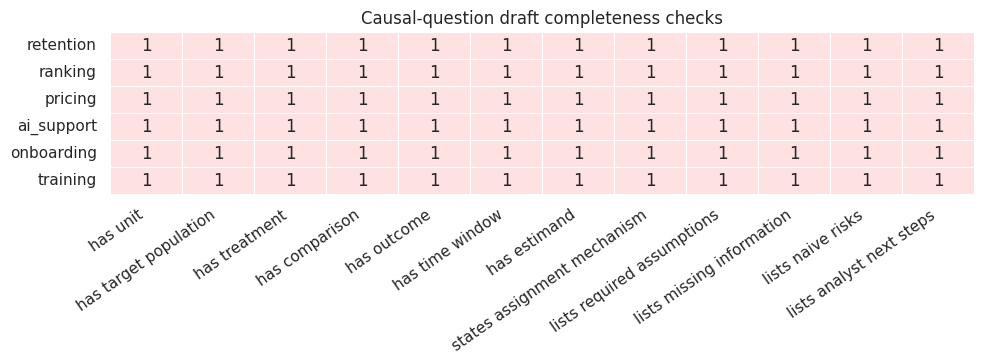

In [115]:
quality_matrix = pd.DataFrame(
    [score_question_draft(draft) | {'case_id': draft.case_id} for draft in drafts]
).set_index('case_id')

fig, ax = plt.subplots(figsize=(10, 3.8))
sns.heatmap(
    quality_matrix.astype(int),
    cmap=sns.color_palette(['#fee2e2', '#dcfce7']),
    cbar=False,
    linewidths=0.5,
    linecolor='white',
    annot=True,
    fmt='d',
    ax=ax,
)
ax.set_title('Causal-question draft completeness checks')
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()


## 7. What a Bad Translation Looks Like

A weak AI translation often fills the structure but hides uncertainty. That is dangerous because the output looks professional while skipping the hard design questions.


In [116]:
bad_draft = {
    'case_id': 'ai_support',
    'stakeholder_question': 'Did the AI support assistant reduce ticket volume?',
    'question_type': 'causal',
    'decision': 'Roll out the AI assistant if ticket volume is lower after launch.',
    'unit': 'tickets',
    'target_population': 'all tickets',
    'treatment': 'AI assistant',
    'comparison': 'before launch',
    'outcome': 'ticket volume',
    'time_window': 'after launch',
    'estimand': 'effect of AI assistant',
    'assignment_mechanism': 'the assistant was launched',
    'required_assumptions': ['the AI assistant caused the change'],
    'missing_information': [],
    'risks_if_answered_naively': [],
    'analyst_next_steps': ['compare before and after averages'],
}

bad = CausalQuestionDraft.model_validate(bad_draft)
bad.model_dump()


{'case_id': 'ai_support',
 'stakeholder_question': 'Did the AI support assistant reduce ticket volume?',
 'question_type': 'causal',
 'decision': 'Roll out the AI assistant if ticket volume is lower after launch.',
 'unit': 'tickets',
 'target_population': 'all tickets',
 'treatment': 'AI assistant',
 'comparison': 'before launch',
 'outcome': 'ticket volume',
 'time_window': 'after launch',
 'estimand': 'effect of AI assistant',
 'assignment_mechanism': 'the assistant was launched',
 'required_assumptions': ['the AI assistant caused the change'],
 'missing_information': [],
 'risks_if_answered_naively': [],
 'analyst_next_steps': ['compare before and after averages']}

In [117]:
def audit_translation_quality(draft):
    warnings = []

    if draft.comparison.lower() in {'before launch', 'before', 'previous period'}:
        warnings.append('Comparison is a before-after contrast; seasonality and demand shocks may confound it.')
    if not draft.missing_information:
        warnings.append('No missing information listed; real business questions usually need clarification.')
    if not draft.risks_if_answered_naively:
        warnings.append('No naive risks listed; this hides identification threats.')

    assumption_text = ' '.join(draft.required_assumptions).lower()
    if 'caused' in assumption_text or 'effect' in assumption_text:
        warnings.append('Assumptions include the conclusion rather than design conditions.')
    if draft.unit.lower() in {'tickets', 'events', 'rows'}:
        warnings.append('Unit may be a measurement event rather than the decision unit that receives treatment.')

    return warnings


audit_result = pd.DataFrame({'warning': audit_translation_quality(bad)})
audit_result


,warning
0,Comparison is a before-after contrast; seasonality and demand shocks may confound it.
1,No missing information listed; real business questions usually need clarification.
2,No naive risks listed; this hides identification threats.
3,Assumptions include the conclusion rather than design conditions.
4,Unit may be a measurement event rather than the decision unit that receives treatment.


### Discussion

The bad draft is structurally valid. It passes the Pydantic schema. But it is causally weak.

This distinction matters throughout the course:

- Schema validation checks whether an output has the right shape.
- Causal validation checks whether the content respects timing, comparison, assignment, and assumptions.

Both are necessary.


## 8. Prompt Pattern: Translate, Do Not Answer

The prompt should forbid causal conclusions and require missing information. A good translation prompt asks the model to make uncertainty explicit.


In [118]:
weak_prompt = 'Did the AI support assistant reduce ticket volume?'

strong_prompt = textwrap.dedent(
    '''
    You are helping draft a causal design document. Do not answer the causal question.
    Translate the stakeholder question into a reviewable causal-question draft.

    Case ID: ai_support
    Stakeholder question:
    Did the AI support assistant reduce ticket volume?

    Business decision to support:
    Should the assistant be rolled out to all support queues?

    Known information:
    - We do not yet know whether rollout was randomized, targeted, phased, queue-based, or global.
    - We do not yet know the eligible population, exact launch timing, exposure definition, or measurement window.
    - We do not yet know whether ticket volume changed because demand changed, measurement changed, or tickets were deflected.

    Return valid JSON only, with these keys:
    case_id, stakeholder_question, question_type, decision, unit, target_population,
    treatment, comparison, outcome, time_window, estimand, assignment_mechanism,
    required_assumptions, missing_information, risks_if_answered_naively, analyst_next_steps.

    The fields required_assumptions, missing_information, risks_if_answered_naively,
    and analyst_next_steps must be JSON arrays of strings, even when there is only one item.

    Rules:
    - Use case_id exactly as ai_support.
    - Do not claim that the assistant worked or caused any outcome.
    - Do not say randomized, A/B test, experiment, or causal effect unless that design is explicitly given.
    - In assignment_mechanism, say that rollout/targeting/randomization must be clarified.
    - In decision, write a business action decision such as "Decide whether to roll out the assistant to all support queues".
    - Do not use phrases like "determine causal impact", "evaluate causal effect", or "measure effectiveness" in the decision field.
    - If rollout, eligibility, timing, or measurement details are missing, list them in missing_information.
    - Flag before-after comparisons, post-treatment variables, measurement changes, ticket deflection, and demand shifts as risks.
    - Make the comparison condition explicit without inventing it.
    - Do not wrap the JSON in Markdown fences.
    '''
).strip()

pd.DataFrame(
    [
        {'prompt type': 'weak', 'prompt': weak_prompt, 'risk': 'Invites the model to answer before design is clear.'},
        {'prompt type': 'strong', 'prompt': strong_prompt, 'risk': 'Channels the model toward a reviewable design artifact.'},
    ]
)


,prompt type,prompt,risk
0,weak,Did the AI support assistant reduce ticket volume?,Invites the model to answer before design is clear.
1,strong,You are helping draft a causal design document. Do not answer the causal question.\nTranslate the stakeholder question into a reviewable...,Channels the model toward a reviewable design artifact.


## 9. Reproducible AI Translation Wrapper

The wrapper below mirrors the pattern from Notebook 02. It uses deterministic examples by default and can call a local model when `RUN_LIVE_LOCAL_LLM = True`.

For public rendering, keep live generation off. For interactive work, run the fast model first, then compare all available models when the prompt and parser are stable.


In [119]:
from pathlib import Path
import sys


def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'notebooks').exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.local_llm import (
    DEFAULT_MODELS_TO_COMPARE,
    build_chat_inputs,
    clean_generated_text,
    clear_loaded_model_cache,
    decode_generated_response,
    format_chat_prompt,
    get_device,
    has_package,
    load_local_model as _shared_load_local_model,
    local_chat as _shared_local_chat,
    move_inputs_to_model_device,
    prepare_chat_inputs,
    set_generation_seed,
)

DEVICE = get_device()


def load_local_model(model_id=MODEL_ID):
    return _shared_load_local_model(model_id)


def decode_generated_text(tokenizer, generated, prompt_token_count, model_id=MODEL_ID):
    return decode_generated_response(tokenizer, generated, prompt_token_count, model_id=model_id)


def local_chat(user_message, system_message=None, model_id=MODEL_ID, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE):
    enabled = globals().get('RUN_LIVE_LOCAL_LLM', globals().get('RUN_LOCAL_LLM', True))
    return _shared_local_chat(
        user_message,
        system_message=system_message,
        model_id=model_id,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        seed=globals().get('SEED', 123),
        enabled=enabled,
    )


def local_generate(user_message, system_message=None, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE):
    return _shared_local_chat(
        user_message,
        system_message=system_message,
        model_id=MODEL_ID,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        seed=globals().get('SEED', 123),
        enabled=globals().get('RUN_LOCAL_LLM', globals().get('RUN_LIVE_LOCAL_LLM', True)),
    )


In [120]:
SYSTEM_TRANSLATOR_MESSAGE = textwrap.dedent(
    '''
    You are a careful causal inference assistant.
    Translate stakeholder questions into causal-question drafts.
    Do not answer whether the treatment worked.
    Do not invent randomization, experiments, eligibility rules, launch timing, or measurement details.
    If assignment is not specified, write that it must be clarified.
    The decision field should describe the business action being supported, not the causal analysis task.
    State missing information explicitly.
    Return valid JSON only when asked for JSON.
    '''
).strip()

FALLBACK_JSON_BY_CASE = {draft.case_id: json.dumps(draft.model_dump(), indent=2) for draft in drafts}


def causal_question_llm(case_id, prompt, model_id=MODEL_ID):
    if RUN_LIVE_LOCAL_LLM:
        return local_chat(prompt, system_message=SYSTEM_TRANSLATOR_MESSAGE, model_id=model_id, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE)
    return FALLBACK_JSON_BY_CASE[case_id]


example_case = 'ai_support'
raw_translation = causal_question_llm(example_case, strong_prompt)
print(raw_translation[:1200])


{
 "case_id": "ai_support",
 "stakeholder_question": "Did the AI support assistant reduce ticket volume?",
 "question_type": "causal",
 "decision": "Decide whether to roll out the assistant to all support queues",
 "unit": "support ticket",
 "target_population": "support queues",
 "treatment": "AI support assistant",
 "comparison": "no AI support assistant",
 "outcome": "ticket volume",
 "time_window": "the period during which the assistant was available",
 "estimand": "average treatment effect on the treated (ATT)",
 "assignment_mechanism": "rollout/targeting/randomization must be clarified",
 "required_assumptions": ["no unobserved confounding variables", "comparable outcomes between treated and comparison groups"],
 "missing_information": ["randomization, targeting, phasing, queue-based or global rollout", "eligible population", "exact launch timing", "exposure definition", "measurement window"],
 "risks_if_answered_naively": ["before-after comparisons may be misleading due to chang

## 10. Parsing and Validating a Model Draft

An LLM may return JSON inside markdown fences, add extra prose, or use a scalar string where the schema expects a list. We use a parser that first tries strict validation, then extracts the JSON object if needed, and finally applies small auditable repairs for common JSON-shape mistakes.


In [121]:
from notebooks._shared.structured_outputs import parse_pydantic_output

LIST_FIELDS = [
    'required_assumptions',
    'missing_information',
    'risks_if_answered_naively',
    'analyst_next_steps',
]

SCALAR_FIELDS = [
    'case_id',
    'stakeholder_question',
    'question_type',
    'decision',
    'unit',
    'target_population',
    'treatment',
    'comparison',
    'outcome',
    'time_window',
    'estimand',
    'assignment_mechanism',
]

QUESTION_DRAFT_ALIASES = {
    'case': 'case_id',
    'id': 'case_id',
    'caseid': 'case_id',
    'case_id': 'case_id',
    'stakeholderquestion': 'stakeholder_question',
    'stakeholder_question': 'stakeholder_question',
    'business_question': 'stakeholder_question',
    'question': 'stakeholder_question',
    'questiontype': 'question_type',
    'question_type': 'question_type',
    'causal_question_type': 'question_type',
    'business_decision': 'decision',
    'decision': 'decision',
    'analysis_unit': 'unit',
    'unit': 'unit',
    'population': 'target_population',
    'target_population': 'target_population',
    'targetpopulation': 'target_population',
    'eligible_population': 'target_population',
    'treatment': 'treatment',
    'intervention': 'treatment',
    'exposure': 'treatment',
    'comparison': 'comparison',
    'counterfactual': 'comparison',
    'control_condition': 'comparison',
    'outcome': 'outcome',
    'metric': 'outcome',
    'time_window': 'time_window',
    'timewindow': 'time_window',
    'timeframe': 'time_window',
    'outcome_window': 'time_window',
    'estimand': 'estimand',
    'causal_estimand': 'estimand',
    'assignment': 'assignment_mechanism',
    'assignment_mechanism': 'assignment_mechanism',
    'assignmentmechanism': 'assignment_mechanism',
    'selection_mechanism': 'assignment_mechanism',
    'required_assumptions': 'required_assumptions',
    'assumptions': 'required_assumptions',
    'identification_assumptions': 'required_assumptions',
    'missing_information': 'missing_information',
    'missing_info': 'missing_information',
    'unknowns': 'missing_information',
    'risks_if_answered_naively': 'risks_if_answered_naively',
    'naive_risks': 'risks_if_answered_naively',
    'risks': 'risks_if_answered_naively',
    'analyst_next_steps': 'analyst_next_steps',
    'next_steps': 'analyst_next_steps',
    'recommended_next_steps': 'analyst_next_steps',
}


def parse_question_draft(raw_output):
    result = parse_pydantic_output(
        raw_output,
        CausalQuestionDraft,
        scalar_fields=SCALAR_FIELDS,
        list_fields=LIST_FIELDS,
        field_aliases=QUESTION_DRAFT_ALIASES,
        nested_keys=['draft', 'causal_question_draft', 'causal_design', 'causal_question', 'translation', 'response'],
    )
    return result.parsed, result.json_text, result.notes


parsed_translation, json_used, parse_errors = parse_question_draft(raw_translation)
if parse_errors:
    print('Parser notes:')
    print(parse_errors)

parsed_translation


CausalQuestionDraft(case_id='ai_support', stakeholder_question='Did the AI support assistant reduce ticket volume?', question_type='causal', decision='Decide whether to roll out the assistant to all support queues', unit='support ticket', target_population='support queues', treatment='AI support assistant', comparison='no AI support assistant', outcome='ticket volume', time_window='the period during which the assistant was available', estimand='average treatment effect on the treated (ATT)', assignment_mechanism='rollout/targeting/randomization must be clarified', required_assumptions=['no unobserved confounding variables', 'comparable outcomes between treated and comparison groups'], missing_information=['randomization, targeting, phasing, queue-based or global rollout', 'eligible population', 'exact launch timing', 'exposure definition', 'measurement window'], risks_if_answered_naively=['before-after comparisons may be misleading due to changes in demand or measurement practices', 'p

## 11. Optional All-Model Comparison

Because these are live local model calls, the exact ranking may change across model versions, package versions, seeds, tokenizer behavior, prompt wording, and reruns. The durable lesson is the evaluation pattern, not the leaderboard. Treat each table as an empirical snapshot of model behavior under this workflow.


For future notebooks, we will compare all available local models when the comparison is substantively useful. Here the comparison task is specific: can each model translate ambiguous business questions into structured causal-question drafts?

This benchmark has two layers:

1. **Structured-output reliability.** Did the model return something that can be parsed and validated against the schema?
2. **Causal-design quality.** Once the output is structurally valid, does it identify the unit, treatment, comparison, outcome, timing, assignment story, assumptions, missing information, and naive-analysis risks?

Those layers should not be collapsed. A model can write fluent causal prose and still fail the workflow because it does not obey the schema. Conversely, a schema-valid answer can still contain a weak causal design.

Keep `RUN_LIVE_LOCAL_LLM = False` and `RUN_FULL_MODEL_COMPARISON = False` for public rendering. Set both to `True` only in an interactive GPU session. When `RUN_SCHEMA_REPAIR_RETRY = True`, failed structured outputs get one repair attempt that asks the same model to convert its own answer to the required JSON schema without adding new claims.

In [122]:
COMPARISON_CASES = ['retention', 'ranking', 'ai_support']

MODEL_COMPARISON_PROMPT_TEMPLATE = textwrap.dedent(
    '''
    Translate this stakeholder question into a causal-question draft.

    Case ID: {case_id}
    Stakeholder question: {stakeholder_question}
    Business decision: {decision}
    Domain: {domain}

    The decision field should preserve the business action decision above.
    It should not say "determine causal impact", "evaluate causal effect", or "measure effectiveness".

    Return JSON with exactly these keys:
    case_id, stakeholder_question, question_type, decision, unit, target_population,
    treatment, comparison, outcome, time_window, estimand, assignment_mechanism,
    required_assumptions, missing_information, risks_if_answered_naively, analyst_next_steps.

    Use the Case ID exactly as the case_id field.
    The last four fields must be arrays of strings, even when there is only one item.
    Return valid JSON only. Do not wrap the JSON in Markdown fences.
    Do not answer whether the treatment worked.
    List missing information rather than inventing it.
    Do not say randomized, A/B test, experiment, instrument, cutoff, or threshold unless that design is explicitly stated above.
    If the assignment mechanism is unclear, say that it must be clarified rather than choosing a design.
    '''
).strip()

SCHEMA_REPAIR_PROMPT_TEMPLATE = textwrap.dedent(
    '''
    Your previous answer could not be parsed as the required causal-question JSON schema.
    Convert the previous answer into valid JSON only.

    Do not add new causal claims.
    Do not answer whether the treatment worked.
    Preserve the stakeholder question and case_id when possible.
    Return one flat JSON object, not nested sections.
    Scalar fields must be strings.
    The fields required_assumptions, missing_information, risks_if_answered_naively,
    and analyst_next_steps must be arrays of strings.

    Parser error:
    {error_message}

    Previous answer:
    {raw_output}
    '''
).strip()

SUMMARY_COLUMNS = [
    'label', 'model_id', 'role', 'cases', 'schema_valid_cases', 'schema_repaired_cases',
    'schema_reliability', 'mean_causal_score', 'failure_types'
]

CASE_RESULT_COLUMNS = [
    'label', 'model_id', 'role', 'case_id', 'status', 'schema_valid', 'repair_used',
    'error_type', 'causal_score', 'max_causal_score', 'causal_score_share', 'error'
]


def prompt_for_case(case_id):
    row = business_questions.set_index('case_id').loc[case_id]
    return MODEL_COMPARISON_PROMPT_TEMPLATE.format(
        case_id=case_id,
        stakeholder_question=row['stakeholder_question'],
        decision=row['decision'],
        domain=row['domain'],
    )


def score_translation_draft(draft):
    checks = score_question_draft(draft)
    decision_text = draft.decision.lower()
    estimand_text = draft.estimand.lower()
    assignment_text = draft.assignment_mechanism.lower()
    missing_text = ' '.join(draft.missing_information).lower()

    causal_conclusion_terms = [
        'because it worked',
        'because it reduced',
        'because it improved',
        'caused a reduction',
        'caused an increase',
        'caused the change',
        'proved effective',
        'causal impact',
        'causal effect',
        'measure effectiveness',
        'determine whether',
        'determine if',
    ]
    unsupported_design_terms = ['randomized', 'a/b test', 'ab test', 'experiment', 'instrument', 'cutoff', 'threshold']
    uncertainty_terms = [
        'clarif',
        'unknown',
        'unclear',
        'must be',
        'need',
        'whether',
        'not randomized',
        'target',
        'self-select',
        'discretion',
        'rollout schedule',
        'queue',
        'operational',
        'likely',
    ]

    invented_randomization = (
        any(term in assignment_text for term in unsupported_design_terms)
        and not any(term in assignment_text for term in ['not randomized', 'whether', 'unknown', 'unclear', 'clarif', 'must be'])
    )

    extra_checks = {
        'question type is causal': draft.question_type.lower() == 'causal',
        'decision is a business action': any(
            term in decision_text for term in ['decide whether', 'should', 'roll out', 'scale', 'keep', 'change', 'required', 'default']
        ),
        'does not answer the effect': not any(term in decision_text for term in causal_conclusion_terms),
        'does not invent assignment design': not invented_randomization,
        'assignment uncertainty is explicit': any(term in assignment_text for term in uncertainty_terms),
        'missing assignment details are listed': any(
            term in missing_text for term in ['assignment', 'rollout', 'random', 'eligibility', 'timing', 'exposure']
        ),
        'estimand remains a target quantity': not any(term in estimand_text for term in ['estimated that', 'found that', 'proved', 'caused a reduction']),
    }
    all_checks = checks | extra_checks
    return int(sum(all_checks.values())), len(all_checks), all_checks


def classify_structured_output_failure(error):
    text = clean_generated_text(repr(error)).lower()
    if 'empty model output' in text:
        return 'empty_output'
    if 'field required' in text or 'missing' in text:
        return 'missing_required_field'
    if 'input should be a valid' in text or 'validation error' in text:
        return 'wrong_field_type_or_schema'
    if 'invalid json' in text or 'expecting value' in text or 'jsondecodeerror' in text:
        return 'invalid_json_or_extra_text'
    return 'other_structured_output_error'


def build_schema_repair_prompt(raw_output, error_message):
    return SCHEMA_REPAIR_PROMPT_TEMPLATE.format(
        raw_output=clean_generated_text(raw_output)[:4000],
        error_message=clean_generated_text(error_message)[:1200],
    )


def parse_or_repair_translation(raw_output, model_id):
    if not clean_generated_text(raw_output):
        raise ValueError('empty model output')

    try:
        parsed, parsed_json, parser_notes = parse_question_draft(raw_output)
        return {
            'parsed': parsed,
            'parsed_json': parsed_json,
            'parser_notes': parser_notes,
            'repair_used': bool(parser_notes),
            'repair_stage': 'parser' if parser_notes else 'none',
            'repaired_raw_output': '',
        }
    except Exception as first_error:
        if not (RUN_SCHEMA_REPAIR_RETRY and RUN_LIVE_LOCAL_LLM):
            raise

        repair_prompt = build_schema_repair_prompt(raw_output, repr(first_error))
        repaired_raw_output = local_chat(
            repair_prompt,
            system_message=SYSTEM_TRANSLATOR_MESSAGE,
            model_id=model_id,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
        )
        parsed, parsed_json, parser_notes = parse_question_draft(repaired_raw_output)
        return {
            'parsed': parsed,
            'parsed_json': parsed_json,
            'parser_notes': [f'first_parse_error: {classify_structured_output_failure(first_error)}'] + parser_notes,
            'repair_used': True,
            'repair_stage': 'model_retry',
            'repaired_raw_output': repaired_raw_output,
        }


def evaluate_model_on_cases(label, model_id, role, case_ids=COMPARISON_CASES):
    rows = []
    artifacts = {}

    for case_id in case_ids:
        prompt = prompt_for_case(case_id)
        raw_output = ''
        repaired_raw_output = ''
        parsed_json = ''
        parser_notes = []
        checks = {}
        error = ''
        error_type = ''
        schema_valid = False
        repair_used = False
        repair_stage = 'none'
        causal_score = np.nan
        max_causal_score = 15

        try:
            raw_output = local_chat(
                prompt,
                system_message=SYSTEM_TRANSLATOR_MESSAGE,
                model_id=model_id,
                max_new_tokens=MAX_NEW_TOKENS,
                temperature=TEMPERATURE,
            )
            parse_result = parse_or_repair_translation(raw_output, model_id)
            parsed = parse_result['parsed']
            parsed_json = parse_result['parsed_json']
            parser_notes = parse_result['parser_notes']
            repair_used = parse_result['repair_used']
            repair_stage = parse_result['repair_stage']
            repaired_raw_output = parse_result['repaired_raw_output']
            causal_score, max_causal_score, checks = score_translation_draft(parsed)
            status = 'ok_after_repair' if repair_used else 'ok'
            schema_valid = True
            error_type = 'none'
        except Exception as exc:
            status = 'schema_error'
            error = repr(exc)[:500]
            error_type = classify_structured_output_failure(exc)

        rows.append(
            {
                'label': label,
                'model_id': model_id,
                'role': role,
                'case_id': case_id,
                'status': status,
                'schema_valid': schema_valid,
                'repair_used': repair_used,
                'repair_stage': repair_stage,
                'error_type': error_type,
                'causal_score': causal_score,
                'max_causal_score': max_causal_score,
                'causal_score_share': causal_score / max_causal_score if pd.notna(causal_score) else 0.0,
                'error': error,
            }
        )
        artifacts[(label, case_id)] = {
            'raw_output': raw_output,
            'repaired_raw_output': repaired_raw_output,
            'parsed_json': parsed_json,
            'parser_notes': parser_notes,
            'checks': checks,
        }

    clear_loaded_model_cache()
    return rows, artifacts


def summarize_model_translation_results(case_results):
    if case_results.empty:
        return pd.DataFrame(columns=SUMMARY_COLUMNS)

    model_summary = (
        case_results.groupby(['label', 'model_id', 'role'], dropna=False)
        .agg(
            cases=('case_id', 'count'),
            schema_valid_cases=('schema_valid', 'sum'),
            schema_repaired_cases=('repair_used', 'sum'),
            mean_causal_score=('causal_score_share', lambda s: s.fillna(0).mean()),
            failure_types=('error_type', lambda s: ', '.join(sorted({str(x) for x in s if str(x) and str(x) != 'none'}))),
        )
        .reset_index()
    )
    model_summary['schema_reliability'] = model_summary['schema_valid_cases'] / model_summary['cases']
    return model_summary[SUMMARY_COLUMNS].sort_values(
        ['schema_reliability', 'mean_causal_score', 'schema_repaired_cases'],
        ascending=[False, False, True],
    )


def summarize_failure_types(case_results):
    if case_results.empty:
        return pd.DataFrame(columns=['error_type', 'cases'])
    return (
        case_results.loc[case_results['error_type'] != 'none']
        .groupby('error_type', dropna=False)
        .size()
        .reset_index(name='cases')
        .sort_values('cases', ascending=False)
    )


def run_all_model_translation_comparison(models_to_compare=MODELS_TO_COMPARE):
    if not RUN_LIVE_LOCAL_LLM:
        raise RuntimeError('Set RUN_LIVE_LOCAL_LLM = True before running the model comparison.')

    rows = []
    artifacts = {}
    for label, model_id, role in models_to_compare:
        print(f'Running {label}: {model_id}')
        model_rows, model_artifacts = evaluate_model_on_cases(label, model_id, role)
        rows.extend(model_rows)
        artifacts.update(model_artifacts)

    case_results = pd.DataFrame(rows, columns=CASE_RESULT_COLUMNS + ['repair_stage'])
    model_summary = summarize_model_translation_results(case_results)
    failure_summary = summarize_failure_types(case_results)
    return case_results, model_summary, failure_summary, artifacts


if RUN_FULL_MODEL_COMPARISON:
    case_comparison_results, model_translation_summary, failure_type_summary, translation_artifacts = run_all_model_translation_comparison()
else:
    model_translation_summary = pd.DataFrame(MODELS_TO_COMPARE, columns=['label', 'model_id', 'role'])
    model_translation_summary['cases'] = len(COMPARISON_CASES)
    model_translation_summary['schema_valid_cases'] = np.nan
    model_translation_summary['schema_repaired_cases'] = np.nan
    model_translation_summary['schema_reliability'] = np.nan
    model_translation_summary['mean_causal_score'] = np.nan
    model_translation_summary['failure_types'] = ''
    model_translation_summary = model_translation_summary[SUMMARY_COLUMNS]
    case_comparison_results = pd.DataFrame(columns=CASE_RESULT_COLUMNS + ['repair_stage'])
    failure_type_summary = pd.DataFrame(columns=['error_type', 'cases'])
    translation_artifacts = {}
    display(Markdown('All-model comparison is configured but not executed. Set `RUN_LIVE_LOCAL_LLM = True` and `RUN_FULL_MODEL_COMPARISON = True` in an interactive GPU session to compare every available model.'))

model_translation_summary


Running Qwen 0.5B: Qwen/Qwen2.5-0.5B-Instruct
Running Qwen 7B: Qwen/Qwen2.5-7B-Instruct


Running Qwen 14B: Qwen/Qwen2.5-14B-Instruct


Running Qwen 32B: Qwen/Qwen2.5-32B-Instruct


Running Phi mini: microsoft/Phi-3.5-mini-instruct


Running Mistral 7B: mistralai/Mistral-7B-Instruct-v0.3


Running Mistral Small 24B: mistralai/Mistral-Small-3.1-24B-Instruct-2503


[transformers] The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Running Gemma 3 27B: google/gemma-3-27b-it


Running Llama 3.1 8B: meta-llama/Meta-Llama-3.1-8B-Instruct


,label,model_id,role,cases,schema_valid_cases,schema_repaired_cases,schema_reliability,mean_causal_score,failure_types
0,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,3,3,3,1.000,1.000,
3,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,3,3,3,1.000,1.000,
1,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,3,3,0,1.000,0.982,
8,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default,3,3,0,1.000,0.965,
7,Qwen 32B,Qwen/Qwen2.5-32B-Instruct,scale comparison,3,3,0,1.000,0.947,
2,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,3,3,3,1.000,0.912,
4,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison,3,3,3,1.000,0.895,
5,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,pipeline smoke test,3,1,1,0.333,0.246,wrong_field_type_or_schema
6,Qwen 14B,Qwen/Qwen2.5-14B-Instruct,strong local analysis,3,0,0,0.000,0.000,wrong_field_type_or_schema


### Discussion

The comparison is intentionally narrow. We are not asking which model is generally best. We are asking which model produces reliable causal-question drafts for this workflow.

The summary table separates two forms of performance:

- `schema_reliability`: the share of cases that became valid `CausalQuestionDraft` objects after strict validation and the allowed repair layer.
- `schema_repaired_cases`: cases that needed either local parser repair or a model retry. These are usable, but they signal operational fragility.
- `mean_causal_score`: the average workflow score across all comparison cases. Structurally failed outputs receive zero causal credit, so the table does not display `NaN` when a model fails every case.
- `failure_types`: compact labels such as `invalid_json_or_extra_text`, `missing_required_field`, or `wrong_field_type_or_schema`.

This distinction is important in industry. A model that writes a persuasive paragraph but breaks the schema can fail an automated workflow. A model that produces valid JSON but gives a weak causal design should also be caught. The operational target is not eloquence; it is a reliable, auditable causal artifact.

## 12. Human Review Checklist

Before moving from a translated question to data analysis, review the draft like a design document.


In [123]:
review_checklist = pd.DataFrame(
    [
        ('decision', 'Is the business decision clear enough to determine the estimand?'),
        ('unit', 'Does the unit receive treatment before the outcome is measured?'),
        ('population', 'Is the target population defined by eligibility before treatment?'),
        ('treatment', 'Is the treatment precise enough to identify in logs?'),
        ('comparison', 'Is the counterfactual comparison condition explicit?'),
        ('outcome', 'Is the outcome meaningful and measured consistently?'),
        ('time', 'Are treatment time and outcome window separated correctly?'),
        ('assignment', 'Do we know how treatment was assigned or selected?'),
        ('assumptions', 'Are untestable assumptions stated rather than hidden?'),
        ('missing info', 'Does the draft list what must be clarified before estimation?'),
        ('naive risk', 'Does the draft explain why a simple comparison might mislead?'),
        ('next step', 'Does the draft tell the analyst what to audit next?'),
    ],
    columns=['area', 'review question'],
)

review_checklist


,area,review question
0,decision,Is the business decision clear enough to determine the estimand?
1,unit,Does the unit receive treatment before the outcome is measured?
2,population,Is the target population defined by eligibility before treatment?
3,treatment,Is the treatment precise enough to identify in logs?
4,comparison,Is the counterfactual comparison condition explicit?
5,outcome,Is the outcome meaningful and measured consistently?
6,time,Are treatment time and outcome window separated correctly?
7,assignment,Do we know how treatment was assigned or selected?
8,assumptions,Are untestable assumptions stated rather than hidden?
9,missing info,Does the draft list what must be clarified before estimation?


## 13. Common Translation Patterns

After enough projects, the same patterns appear again and again.


In [124]:
translation_patterns = pd.DataFrame(
    [
        ('Did X work?', 'effect of assignment to X compared with the previous or standard condition', 'Define X, comparison condition, target population, and outcome window.'),
        ('Did launch improve metrics?', 'effect of new policy/product version compared with old version', 'Clarify rollout, seasonality, exposure, and guardrails.'),
        ('Are users who got X better?', 'effect of receiving X, not merely association among selected users', 'Audit targeting, selection, and baseline risk.'),
        ('Should we scale X?', 'effect or policy value of assigning X to the future eligible population', 'Check whether historical treated units represent rollout units.'),
        ('Did AI reduce workload?', 'effect of AI enablement on work volume and quality guardrails', 'Separate true demand reduction from measurement and deflection effects.'),
    ],
    columns=['stakeholder wording', 'causal rewrite pattern', 'main warning'],
)

translation_patterns


,stakeholder wording,causal rewrite pattern,main warning
0,Did X work?,effect of assignment to X compared with the previous or standard condition,"Define X, comparison condition, target population, and outcome window."
1,Did launch improve metrics?,effect of new policy/product version compared with old version,"Clarify rollout, seasonality, exposure, and guardrails."
2,Are users who got X better?,"effect of receiving X, not merely association among selected users","Audit targeting, selection, and baseline risk."
3,Should we scale X?,effect or policy value of assigning X to the future eligible population,Check whether historical treated units represent rollout units.
4,Did AI reduce workload?,effect of AI enablement on work volume and quality guardrails,Separate true demand reduction from measurement and deflection effects.


## 14. Key Takeaways

- A business question is not yet a causal question.
- A causal question needs a unit, target population, treatment, comparison condition, outcome, time window, estimand, and assignment story.
- AI is useful for making ambiguity visible, but it should not answer the causal question before the design is clear.
- Structured outputs are helpful because they make missing fields and unsafe assumptions easier to audit.
- Schema validation is not causal validation. A valid JSON object can still contain a weak causal design.
- Structured-output reliability and causal-design quality should be evaluated separately.
- A validation-repair-revalidation loop is a practical engineering pattern, but repaired outputs should be marked rather than silently treated as pristine.
- In future notebooks, model comparisons should include all available models when the task is model-sensitive, but the score must be tied to the causal artifact.

The next notebook turns these translated questions into richer estimand cards and causal design documents.
